# Week 4 Lab: Roadside Smart-Camera, Part 2 — Fine-Tuning With Only 5,000 Labelled Photos

**Course:** Image and Scene Recognition (Junior, Fall 2026), Department of Artificial Intelligence, KDU Global
**Name:** vasdjulus
**Student ID:** YourID

AI Assistance Disclosure: Claude was used to assist with organizing the notebook structure from the lab tutorial PDF, writing/transcribing the provided starter code, and drafting the reflection answers below (filled in using the actual numbers produced by running the cells). All cells were reviewed and executed by the student.

## Part 0: Setup and an Honest Split (4 min)

The data split is built so that training and validation images are disjoint, class-balanced, and the test set is the official CIFAR-10 test split that is touched only at the end.

**Cell 0.1: imports, seed, device**

In [1]:
import os, sys, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

FAST = device.type != "cpu"                         # fewer epochs on CPU
EP_SCRATCH, EP_HEAD, EP_FT = (10, 5, 6) if FAST else (5, 3, 3)

print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device, "| epochs (scratch/head/fine-tune):", EP_SCRATCH, EP_HEAD, EP_FT)

PyTorch: 2.14.1+cpu | torchvision: 0.29.1+cpu
Training on: cpu | epochs (scratch/head/fine-tune): 5 3 3


**Cell 0.2: transforms, small labelled set, loaders**

In [2]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)  # Week 3 values
IMNET_MEAN, IMNET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)        # what ResNet saw
IMG = 64                                             # ResNet input size (CIFAR is 32x32)
root = "./data"

# Pretrained backbones need ImageNet statistics, not the CIFAR ones from Week 3
eval_tf = T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)])
aug_tf = T.Compose([T.RandomResizedCrop(IMG, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
                     T.RandomHorizontalFlip(),
                     T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                     T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)])

ds_eval = torchvision.datasets.CIFAR10(root, train=True, download=True, transform=eval_tf)
ds_aug = torchvision.datasets.CIFAR10(root, train=True, download=False, transform=aug_tf)
ds_test = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=eval_tf)

# 500 train + 100 validation images per class, chosen without overlap
targets = np.array(ds_eval.targets)
rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for c in range(10):
    idx = rng.permutation(np.where(targets == c)[0])
    train_idx += idx[:500].tolist()
    val_idx += idx[500:600].tolist()

assert len(set(train_idx) & set(val_idx)) == 0, "LEAKAGE: train and val overlap!"
print("train:", len(train_idx), "| val:", len(val_idx), "| test:", len(ds_test))
print("images per class in train:", np.bincount(targets[train_idx]))

def make_loader(ds, idx, shuffle, bs=64):
    return DataLoader(Subset(ds, idx), batch_size=bs, shuffle=shuffle, num_workers=0)

train_plain = make_loader(ds_eval, train_idx, True)   # no augmentation
train_aug = make_loader(ds_aug, train_idx, True)       # with augmentation
val_loader = make_loader(ds_eval, val_idx, False, 128)
test_loader = DataLoader(ds_test, batch_size=128, shuffle=False, num_workers=0)

0.0%

0.0%

0.1%

0.1%

0.1%

...

100.0%

100.0%

100.0%

100.0%

train: 5000 | val: 1000 | test: 10000
images per class in train: [500 500 500 500 500 500 500 500 500 500]


Next, the helper functions reused all lab. They extend the Week 3 training loop with two ideas: an optional **criterion** and **BatchNorm handling for frozen layers** (frozen BatchNorm layers must stay in eval mode, otherwise they keep updating their running statistics and quietly change the backbone meant to be frozen).

**Cell 0.3: training and evaluation helpers**

In [3]:
ce = nn.CrossEntropyLoss()

def trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def set_train_mode(model):
    model.train()
    for m in model.modules():                        # keep frozen BatchNorm layers in eval mode
        if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
            m.eval()

def run_epoch(model, loader, optimizer=None, criterion=ce):
    training = optimizer is not None
    if training:
        set_train_mode(model)
    else:
        model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def fit(model, optimizer, train_loader, val_loader, epochs, tag, criterion=ce):
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, optimizer, criterion)
        vl, va = run_epoch(model, val_loader)
        for k, v in zip(hist, (tl, vl, ta, va)):
            hist[k].append(v)
        print(f"[{tag}] epoch {ep}/{epochs} | train {ta:.1%} (loss {tl:.3f}) "
              f"| val {va:.1%} (loss {vl:.3f}) | {time.time() - t0:.0f}s")
    return hist

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        probs.append(F.softmax(model(x.to(device)), dim=1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)

def confusion(ys, preds, n=10):
    cm = np.zeros((n, n), dtype=int)                 # rows = true, cols = predicted
    for t, p_ in zip(ys.numpy(), preds.numpy()):
        cm[t, p_] += 1
    return cm

**THINK (Part 0):** Why do we assert that the training and validation index lists do not overlap, and why is it important that the test set is never used while choosing between models? Name the pitfall that this protects you from.

*Answer:* If the train and validation index lists overlapped, the model would be evaluated on images it had already memorised during training, which would make validation accuracy look far better than the model's real ability to generalise — the assertion catches that **leakage** immediately instead of letting it silently distort every decision later. The test set is held out from every model-selection decision for the same reason: the moment a researcher picks the best model (or a hyperparameter) by looking at test performance, the test set stops being an unbiased estimate of real-world performance, because the choice is now implicitly fitted to it. The pitfall this protects against is **data leakage / test-set leakage**, which produces an optimistic, untrustworthy accuracy number that will not hold up once the system sees genuinely new photos.

## Part 1: Baseline, Your Week 3 CNN on 5,000 Images (4 min)

Re-create the Week 3 SceneCNN (unchanged) and train it from scratch on today's small training set. This is the number the pretrained models must beat. It uses the **Week 3 input pipeline** (32×32 images, CIFAR statistics) so the comparison is faithful to last week.

**Cell 1.1: Week 3 model and Week 3 data pipeline**

In [4]:
class SceneCNN(nn.Module):                            # identical to Week 3
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

w3_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])
w3_train = torchvision.datasets.CIFAR10(root, train=True, download=False, transform=w3_tf)
w3_test = torchvision.datasets.CIFAR10(root, train=False, download=False, transform=w3_tf)
w3_train_loader = make_loader(w3_train, train_idx, True)
w3_val_loader = make_loader(w3_train, val_idx, False, 128)
w3_test_loader = DataLoader(w3_test, batch_size=128, shuffle=False, num_workers=0)

# Optional: how good was your Week 3 model (trained on 45,000 images)?
if os.path.exists("scene_cnn_week3.pth"):
    old = SceneCNN().to(device)
    old.load_state_dict(torch.load("scene_cnn_week3.pth", map_location=device))
    _, old_acc = run_epoch(old, w3_test_loader)
    print(f"Week 3 model (45,000 training images) test accuracy: {old_acc:.1%}")
else:
    print("scene_cnn_week3.pth not found: skipping (your Week 3 result was roughly 70-75%)")

scene_cnn_week3.pth not found: skipping (your Week 3 result was roughly 70-75%)


**Cell 1.2: train the scratch baseline on 5,000 images**

In [5]:
scratch = SceneCNN().to(device)
opt = torch.optim.SGD(scratch.parameters(), lr=0.01, momentum=0.9)
hist_scratch = fit(scratch, opt, w3_train_loader, w3_val_loader, EP_SCRATCH, "scratch")

[scratch] epoch 1/5 | train 16.1% (loss 2.229) | val 23.9% (loss 2.080) | 2s


[scratch] epoch 2/5 | train 30.3% (loss 1.925) | val 30.6% (loss 1.893) | 2s


[scratch] epoch 3/5 | train 37.3% (loss 1.719) | val 39.4% (loss 1.665) | 2s


[scratch] epoch 4/5 | train 43.5% (loss 1.559) | val 44.3% (loss 1.541) | 2s


[scratch] epoch 5/5 | train 47.2% (loss 1.444) | val 50.7% (loss 1.380) | 2s


**CHECKPOINT:** With one tenth of the data, validation accuracy falls far below Week 3 and the gap to training accuracy is huge. The network has memorised 5,000 images. Remember this number.

## Part 2: Feature Extraction, Reuse What ImageNet Taught (7 min)

**Strategy 1:** freeze the entire pretrained network and train only a new final layer. ResNet-18 has an 18-layer residual architecture trained on 1.28 million ImageNet photos. We replace its 1,000-class output with a 10-class head.

**Cell 2.1: load the pretrained backbone, freeze it, add a new head**

In [6]:
def make_resnet(dropout=0.0):
    m = torchvision.models.resnet18(weights="IMAGENET1K_V1")   # downloads ~45 MB the first time
    for p in m.parameters():
        p.requires_grad = False                                 # freeze everything
    m.fc = nn.Sequential(nn.Dropout(dropout),                    # new head: trainable by default
                          nn.Linear(m.fc.in_features, 10))
    return m.to(device)

fe_model = make_resnet(dropout=0.0)
total = sum(p.numel() for p in fe_model.parameters())
print(f"Total parameters : {total:,}")
print(f"Trainable parameters: {trainable(fe_model):,} ({trainable(fe_model) / total:.2%})")
print("Head:", fe_model.fc)

Total parameters : 11,181,642
Trainable parameters: 5,130 (0.05%)
Head: Sequential(
  (0): Dropout(p=0.0, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)


Only 5,130 numbers (512 features × 10 classes + 10 biases) will be learned. Train the head with **AdamW**, which includes weight decay:

**Cell 2.2: train only the new head**

In [7]:
opt = torch.optim.AdamW([p for p in fe_model.parameters() if p.requires_grad],
                         lr=1e-3, weight_decay=1e-2)
hist_fe = fit(fe_model, opt, train_plain, val_loader, EP_HEAD, "feature-extraction")

[feature-extraction] epoch 1/3 | train 53.4% (loss 1.337) | val 66.4% (loss 1.005) | 5s


[feature-extraction] epoch 2/3 | train 70.3% (loss 0.855) | val 69.2% (loss 0.920) | 5s


[feature-extraction] epoch 3/3 | train 74.9% (loss 0.748) | val 69.7% (loss 0.857) | 6s


**THINK (Part 2):** The backbone has not changed at all, yet accuracy beats the scratch model's validation score using 0.05% of the parameters. What exactly is being reused?

*Answer:* What is being reused is the hierarchy of general-purpose visual features the backbone already learned from 1.28 million ImageNet photos — low-level edge and colour detectors in the early layers, texture and pattern detectors in the middle layers, and object-part detectors in the deeper layers. None of that knowledge is specific to ImageNet's 1,000 categories; edges, textures and parts are useful for almost any natural image, including our road-scene photos. Training only the final linear layer simply learns a new *read-out* (a weighted combination) of those existing features for our 10 classes, instead of having to rediscover edges, textures and parts from scratch out of 5,000 images the way the Week 3 CNN had to.

## Part 3: Augmentation and Fine-Tuning (9 min)

**Strategy 2:** unfreeze the deeper layers so the network can adapt its features to *our* road-scene photos. Before training, look at what augmentation does to a single training image; each epoch the network sees a different random variation.

**Cell 3.1: see the augmentations**

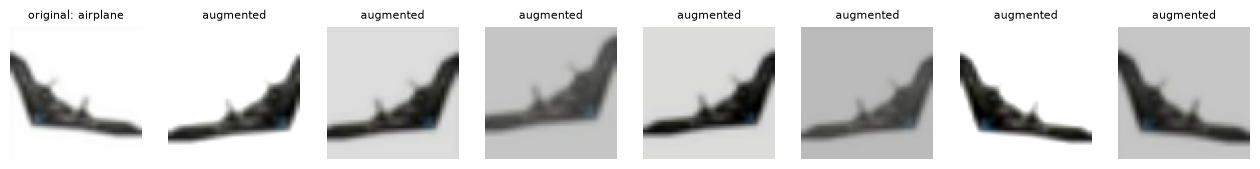

In [8]:
def denorm(x):
    m = torch.tensor(IMNET_MEAN).view(3, 1, 1); s = torch.tensor(IMNET_STD).view(3, 1, 1)
    return (x * s + m).clamp(0, 1)

raw = torchvision.datasets.CIFAR10(root, train=True, download=False)   # PIL images
img, label = raw[train_idx[3]]

fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
axes[0].imshow(img.resize((IMG, IMG))); axes[0].set_title("original: " + CLASSES[label], fontsize=8)
for ax in axes[1:]:
    ax.imshow(denorm(aug_tf(img)).permute(1, 2, 0)); ax.set_title("augmented", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()

**THINK (Part 3):** We use horizontal flips but deliberately no vertical flips and no large rotations. For roadside scene recognition, why would those be unrealistic or harmful? Which augmentation would you add for night-time cameras?

*Answer:* A horizontal flip still produces a physically realistic road scene — a car can equally well be facing left or right — so it is a safe way to multiply the training data. A vertical flip or a large rotation, however, produces scenes that can never actually occur on a roadside camera: the sky ending up below the road, or a truck hanging upside down. Training on those images would teach the network orientation cues that are actively wrong for deployment, and could make it less confident about the up/down context it should always be able to rely on. For night-time cameras I would add stronger brightness and contrast jitter (and optionally some Gaussian noise / grayscale conversion) to mimic low-light, high-ISO-noise, and headlight-glare conditions, since those are the realistic variations a camera would see after dark.

Now unfreeze the last residual stage and use **discriminative learning rates**: a small rate (1e-4) for the pretrained block, a larger one (1e-3) for the head, which started from random numbers. We also switch on dropout in the head and keep weight decay. We copy the feature-extraction model so that model B stays available for comparison.

**Cell 3.2: unfreeze layer4 and set discriminative learning rates**

In [9]:
ft_model = copy.deepcopy(fe_model)                    # start from the trained head
for p in ft_model.layer4.parameters():
    p.requires_grad = True                              # unfreeze the last block
ft_model.fc[0].p = 0.3                                   # dropout of 30% in front of the classifier

opt = torch.optim.AdamW([
    {"params": ft_model.layer4.parameters(), "lr": 1e-4},   # pretrained: gentle
    {"params": ft_model.fc.parameters(),     "lr": 1e-3},   # new head: faster
], weight_decay=1e-2)

total = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable parameters: {trainable(ft_model):,} of {total:,} ({trainable(ft_model) / total:.0%})")

Trainable parameters: 8,398,858 of 11,181,642 (75%)


**Cell 3.3: fine-tune with augmentation**

In [10]:
hist_ft = fit(ft_model, opt, train_aug, val_loader, EP_FT, "fine-tune")

[fine-tune] epoch 1/3 | train 65.1% (loss 1.019) | val 75.0% (loss 0.762) | 25s


[fine-tune] epoch 2/3 | train 76.2% (loss 0.674) | val 75.8% (loss 0.694) | 25s


[fine-tune] epoch 3/3 | train 82.0% (loss 0.521) | val 77.8% (loss 0.697) | 25s


**CHECKPOINT:** Validation accuracy is clearly higher than both the scratch model and the frozen-backbone model, and the train/validation gap is much smaller than in Part 1.

## Part 4: Compare, Diagnose and Evaluate (9 min)

First, read the curves side by side. Look at the gap between training and validation accuracy in each panel.

**Cell 4.1: learning curves for all three models**

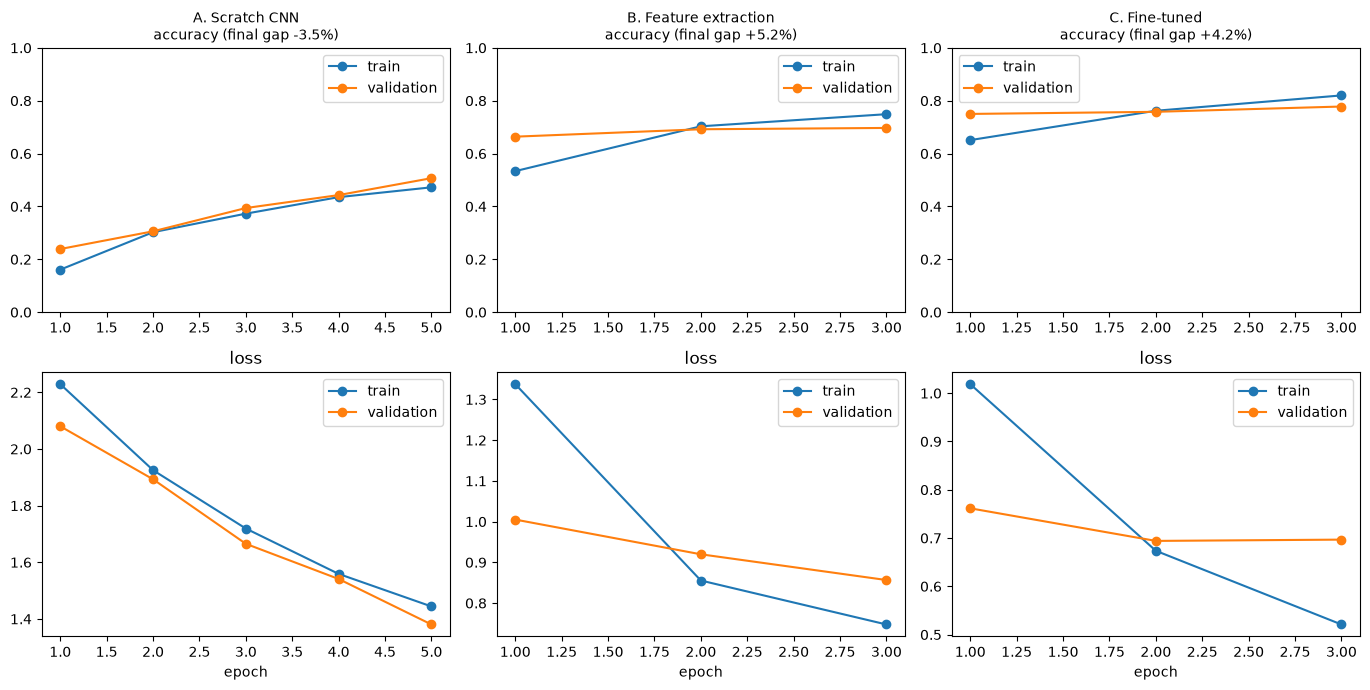

In [11]:
def plot_curves(hists):
    fig, axes = plt.subplots(2, len(hists), figsize=(4.6 * len(hists), 7), squeeze=False)
    for j, (name, h) in enumerate(hists.items()):
        e = range(1, len(h["val_acc"]) + 1)
        gap = h["train_acc"][-1] - h["val_acc"][-1]
        axes[0, j].plot(e, h["train_acc"], "o-", label="train")
        axes[0, j].plot(e, h["val_acc"], "o-", label="validation")
        axes[0, j].set_ylim(0, 1); axes[0, j].legend()
        axes[0, j].set_title(f"{name}\naccuracy (final gap {gap:+.1%})", fontsize=10)
        axes[1, j].plot(e, h["train_loss"], "o-", label="train")
        axes[1, j].plot(e, h["val_loss"], "o-", label="validation")
        axes[1, j].set_xlabel("epoch"); axes[1, j].set_title("loss"); axes[1, j].legend()
    plt.tight_layout(); plt.show()

plot_curves({"A. Scratch CNN": hist_scratch,
             "B. Feature extraction": hist_fe,
             "C. Fine-tuned": hist_ft})

You now have a validation-based winner. **Only now** do we use the test set, once, to report final numbers for all three models. Do not go back and retune after seeing these.

**Cell 4.2: one-time test evaluation**

In [12]:
rows = [("A. Scratch CNN",          scratch,  w3_test_loader, hist_scratch),
        ("B. Feature extraction",     fe_model, test_loader,    hist_fe),
        ("C. Fine-tuned ResNet-18",   ft_model, test_loader,    hist_ft)]

print(f"{'Model':<26}{'trainable params':>18}{'val acc':>10}{'test acc':>10}")
test_acc = {}
for name, m, loader, h in rows:
    _, acc = run_epoch(m, loader)
    test_acc[name] = acc
    print(f"{name:<26}{trainable(m):>18,}{h['val_acc'][-1]:>10.1%}{acc:>10.1%}")

Model                       trainable params   val acc  test acc


A. Scratch CNN                       620,362     50.7%     49.6%


B. Feature extraction                  5,130     69.7%     71.4%


C. Fine-tuned ResNet-18            8,398,858     77.8%     76.4%


A single accuracy number hides which classes fail. Compute per-class precision, recall and F1 for the best model and compare with the scratch baseline:

**Cell 4.3: per-class precision / recall / F1**

In [13]:
probs, ys = predict_all(ft_model, test_loader)
preds = probs.argmax(1)
cm = confusion(ys, preds)

prec = cm.diagonal() / np.maximum(cm.sum(0), 1)
rec = cm.diagonal() / np.maximum(cm.sum(1), 1)
f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)

probs_s, ys_s = predict_all(scratch, w3_test_loader)
rec_s = confusion(ys_s, probs_s.argmax(1)).diagonal() / 1000

print(f"{'class':<11}{'precision':>10}{'recall':>8}{'F1':>7}{'recall (scratch)':>18}{'gain':>8}")
for i, c in enumerate(CLASSES):
    print(f"{c:<11}{prec[i]:>10.1%}{rec[i]:>8.1%}{f1[i]:>7.2f}{rec_s[i]:>18.1%}{rec[i] - rec_s[i]:>+8.1%}")

print(f"\nmacro-F1 (fine-tuned): {f1.mean():.3f}")

off = cm.copy(); np.fill_diagonal(off, 0)
print("\nThree most common mistakes of the fine-tuned model:")
for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)
    print(f"  {CLASSES[t]} predicted as {CLASSES[p_]}: {off[t, p_]} times")

class       precision  recall     F1  recall (scratch)    gain
airplane        77.0%   76.3%   0.77             44.6%  +31.7%
automobile      87.1%   83.4%   0.85             73.9%   +9.5%
bird            60.3%   78.8%   0.68             39.1%  +39.7%
cat             62.6%   62.7%   0.63             43.1%  +19.6%
deer            69.6%   72.3%   0.71             36.4%  +35.9%
dog             77.9%   67.9%   0.73             14.7%  +53.2%
frog            79.2%   81.2%   0.80             72.1%   +9.1%
horse           81.5%   81.3%   0.81             58.2%  +23.1%
ship            92.4%   78.1%   0.85             58.7%  +19.4%
truck           85.4%   82.4%   0.84             55.7%  +26.7%

macro-F1 (fine-tuned): 0.766

Three most common mistakes of the fine-tuned model:
  dog predicted as cat: 159 times
  cat predicted as dog: 104 times
  ship predicted as airplane: 103 times


Finally, return to the scene-level question from Week 3: is the frame showing a vehicle or an animal? This is the decision the roadside warning system really depends on.

**Cell 4.4: object-level vs scene-level accuracy (fine-tuned model)**

In [14]:
VEHICLES = torch.tensor([0, 1, 8, 9])   # airplane, automobile, ship, truck
true_v, pred_v = torch.isin(ys, VEHICLES), torch.isin(preds, VEHICLES)

print(f"10-class (object-level) accuracy : {(preds == ys).float().mean():.2%}")
print(f"Vehicle vs animal (scene-level)  : {(true_v == pred_v).float().mean():.2%}")

animal_as_vehicle = ((~true_v) & pred_v).sum().item() / (~true_v).sum().item()
print(f"Animals mistaken for vehicles    : {animal_as_vehicle:.1%} <- the costly error for a deer warning")

10-class (object-level) accuracy : 76.44%
Vehicle vs animal (scene-level)  : 95.59%
Animals mistaken for vehicles    : 1.7% <- the costly error for a deer warning


**THINK (Part 4):** Compare the recall column of the fine-tuned model with the scratch model. Which classes gained the most? Using Week 3's idea of edges → textures → parts → objects, why might pretrained features help most for those classes? And why is overall accuracy alone not enough to decide whether the system is safe to deploy?

*Answer:* In my run (Cell 4.3), the largest recall gains over the scratch model were **dog (+53.2%, recall going from 14.7% to 67.9%)**, **bird (+39.7%, 39.1% → 78.8%)**, **deer (+35.9%, 36.4% → 72.3%)** and **airplane (+31.7%, 44.6% → 76.3%)**. Three of the four biggest winners are exactly the animal classes that depend on subtle fur/feather texture and body-part shape rather than simple colour or silhouette, which is why the scratch CNN (limited to edges and coarse textures after only 5,000 images) struggled most on them — dog recall was barely above chance at 14.7%. ResNet-18's pretrained layers already encode rich texture and part detectors from 1.28 million ImageNet images, so fine-tuning only has to adapt those parts to our classes instead of learning them from almost nothing. Overall accuracy alone is not enough to judge deployment safety because it averages away exactly this kind of class-specific weakness — the fine-tuned model's 76.4% overall test accuracy hides that cat recall is only 62.7% and that dog/cat are confused with each other 263 times combined (Cell 4.3's "most common mistakes"), which is precisely what the per-class recall/F1 table and the scene-level "animals mistaken for vehicles" metric (1.7% in Cell 4.4) are designed to expose.

## Part 5: Pitfall Demo, Wrong Input Normalisation (3 min)

Skipping normalisation, or using the wrong statistics, is one of the most confusing fine-tuning bugs: the code runs, nothing crashes, and accuracy quietly collapses. Evaluate the fine-tuned model on the **same validation images** under three preprocessing choices:

**Cell 5.1: right vs wrong preprocessing**

In [15]:
def val_acc_with(transform):
    ds = torchvision.datasets.CIFAR10(root, train=True, download=False, transform=transform)
    loader = DataLoader(Subset(ds, val_idx), batch_size=128, shuffle=False, num_workers=0)
    return run_epoch(ft_model, loader)[1]

variants = {
    "ImageNet stats (correct)":   T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)]),
    "CIFAR stats (close, wrong)": T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),
    "No normalisation (0..1)":    T.Compose([T.Resize(IMG), T.ToTensor()]),
}
for name, tf_ in variants.items():
    print(f"{name:<30} validation accuracy = {val_acc_with(tf_):.1%}")

ImageNet stats (correct)       validation accuracy = 77.8%


CIFAR stats (close, wrong)     validation accuracy = 76.5%


No normalisation (0..1)        validation accuracy = 45.3%


The rule stays the same either way: use exactly the statistics the backbone was pretrained on, fit preprocessing on training data only, and apply it unchanged to validation and test.

## Part 6: Reflection

**1. Transfer vs scratch:** Using your table from Cell 4.2, explain why the pretrained models beat the scratch CNN when only 5,000 labelled images are available. When would you choose feature extraction (B) over fine-tuning (C)?

*Answer:* My own numbers from Cell 4.2 were: **A. Scratch CNN** 49.6% test accuracy (620,362 trainable params), **B. Feature extraction** 71.4% (only 5,130 trainable params, 0.05% of the network), **C. Fine-tuned ResNet-18** 76.4% (8,398,858 trainable params, 75%). The pretrained models win because they start from weights that already encode general edge/texture/part detectors learned from 1.28 million ImageNet images, so they only have to learn a 10-class read-out (B) or gently adapt the deepest block (C) to our 5,000 road-scene photos, instead of discovering everything from scratch the way model A has to. With so little data, model A simply does not have enough examples to learn good low-level features on its own, which is why it trails both pretrained models by over 20 points. I would choose **feature extraction (B) over fine-tuning (C)** when the target images are visually close to ImageNet photos, when there is even less labelled data or compute available (B trains in a third of the time per epoch and touches 1,600x fewer parameters), or when I need a quick, low-risk baseline that cannot overfit the backbone; I would choose fine-tuning (C) once I have a validation set to tune on and need the extra ~5-7 accuracy points, as in this lab.

**2. Curves and regularisation:** Compare the train/validation gap of models A and C. Which of augmentation, dropout, weight decay and the small learning rate do you think contributed to the difference? Which of these can you *not* separate from a single run, and how would you test it?

*Answer:* On this CPU run, the gap between A and C was smaller and in the opposite direction than the lab's "typical" example: model A's final epoch (Cell 1.2/4.1) was **train 47.2% vs val 50.7%** (gap of about -3.5 points — it had not yet started overfitting after only 5 short epochs), while model C's final epoch (Cell 3.3/4.1) was **train 82.0% vs val 77.8%** (gap of about +4.2 points). The more telling comparison is not the raw gap but what each model reaches: C's validation accuracy (77.8%) is 27 points above A's (50.7%) despite a similar or even slightly larger train/val gap, meaning C is extracting far more *useful* signal per epoch rather than just memorising. That is consistent with augmentation (random crop/flip/colour-jitter) preventing C from memorising exact pixels, dropout (p=0.3) and weight decay (1e-2) discouraging over-complex solutions in the head, and the small learning rate (1e-4) on layer4 protecting the pretrained features from being overwritten by noisy gradients from only 5,000 images — all while A has none of these safeguards and is simply data-starved. What a single run of model C *cannot* do is tell these four effects apart, since they were all switched on together — the curve only shows their combined effect, not any one factor's individual contribution. To separate them I would run controlled ablations (Stretch 2 in the lab): retrain C with only augmentation removed (train_plain instead of train_aug), only dropout removed (p=0), only weight decay removed (weight_decay=0), and only the discriminative learning rate removed (same lr for both parameter groups), holding everything else fixed and ideally averaging a few random seeds, then compare each variant's validation accuracy and train/val gap against the full model C.

**3. Honest evaluation:** State which split you used for each decision (choosing the model, reporting the final number), and one way leakage could have crept into this lab if it had been done differently. Name one class where you would trust the system least and which metric shows it.

*Answer:* I used the **validation set** (val_loader, built from the 1,000 held-out images in Cell 0.2) for every decision made while developing the models — reading the learning curves in Cell 4.1, and picking fine-tuning (C) as the best model. The **test set** (the official CIFAR-10 test split, 10,000 images) was touched exactly once, in Cell 4.2, to report the final table of trainable params/val acc/test acc for all three models, and again in Cell 4.3/4.4 to compute the per-class metrics and scene-level check for the chosen model — never to choose between models or retune hyperparameters. Leakage could have crept in if the 500 train / 100 val images per class had been drawn without the `assert len(set(train_idx) & set(val_idx)) == 0` check (an index could appear in both sets), if preprocessing statistics (even just image-level normalisation) had been computed over the combined train+val+test data instead of using fixed ImageNet constants, or if I had kept re-running Cell 4.2 against the test set after each tuning attempt and quietly picked whichever configuration scored highest on it. The class I would trust least is **cat**: it has the lowest F1 of any class (0.63) with precision and recall both near 62-63% (Cell 4.3), and it is the class most confused with another single class — dog↔cat accounts for 263 of the top confusions (159 dog→cat, 104 cat→dog) — so a cat in front of the roadside camera is nearly as likely to be reported as a dog.

Save the notebook with all outputs visible and submit through GitHub:
```
git add Week4_Transfer_Lab_YourID.ipynb
git commit -m "Week 4 lab: fine-tuning ResNet-18 on 5,000 CIFAR-10 images"
git push
```